## Building and Analyzing Binary Classification Systems

#### Machine Learning Alrorithms

#### By Jay Vardhan Ghildiyal, a1953779

## Installing Libraries (optional)

to run this notebook, one may download **Anaconda** to get all necessary libraries.

otherwise, execute the cell below. it contains all the pip (python's package manager) commands i used to manually install the required libraries.

In [ ]:
# not required. run cell if you don't have these libraries already
%pip install numpy
%pip install matplotlib
%pip install sklearn
%pip install seaborn

## Data Exploration and Analysis

### Data Inspection

we start by loading our dataset and analyzing the data inside

In [64]:
import numpy as np

# loading the dataset
data = np.load("mnist_1_7_subsets.npz")

# checking the data type of the data variable
print(type(data))
# so this is a dictionary, as opposed to a pandas dataframe

# checking the keys of the data variable
print(list(data.keys()))

<class 'numpy.lib.npyio.NpzFile'>
['train_data', 'train_targets', 'test_data', 'test_targets']


the dataset is a `numpy.lib.npyio.NpzFile` file, which is a NumPy zip file object. it's basically a container that holds multiple arrays inside it (like a dictionary).

In [62]:
# create different arrays for each key
X_train = data["train_data"]
y_train = data["train_targets"]
X_test = data["test_data"]
y_test = data["test_targets"]

# print each array's dimensions
print("X_train shape : ", X_train.shape)
print("y_train shape : ", y_train.shape)
print("X_test shape : ", X_test.shape)
print("y_test shape : ", y_test.shape)

X_train shape :  (100, 28, 28)
y_train shape :  (100,)
X_test shape :  (1000, 28, 28)
y_test shape :  (1000,)


we have 100 samples for training and a 1000 samples for testing. each sample has a 28x28 grayscale image (784 features or pixels) with it.

the image is present in the form of a 28x28 matrix. each singular value in that matrix represents a pixel. 

each pixel has a numerical value that representing it's brightness, ranging from 0 to 255 :

- 0 = black
- 255 = white
- anything in between 0 to 255 = a shade of grey

In [63]:
# checking for unique labels in the training data
print("training labels : ", np.unique(y_train))

# loop through each unique label
# and count the number of samples for that label
print("class counts in training set : ")
for label in np.unique(y_train) :
    print(f"  digit {label} : {np.sum(y_train == label)} samples")

print("\nclass counts in test set : ")
for label in np.unique(y_test) :
    print(f"  digit {label} : {np.sum(y_test == label)} samples")

training labels :  [1 7]
class counts in training set : 
  digit 1 : 50 samples
  digit 7 : 50 samples

class counts in test set : 
  digit 1 : 100 samples
  digit 7 : 900 samples


we see something interesting by looking at the data distribution:

- test digit 1: 100 samples
- test digit 7: 900 samples

this means that if our model learns to predict the **digit 7** for the most part, it would give a false sense of accuracy. this warrants using metrics like precision, recall and f1 score.

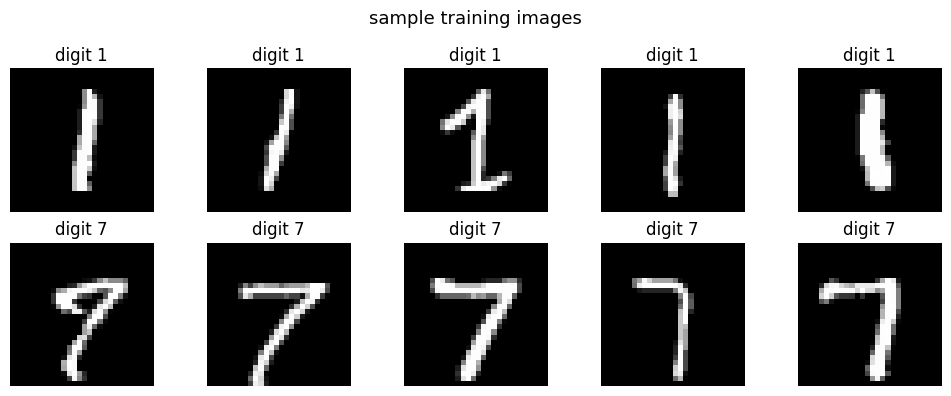

In [5]:
import matplotlib.pyplot as plt

# create a 2 x 5 grid with image ratio as 10 : 4
fig, axes = plt.subplots(2, 5, figsize = (10, 4))

for i, digit in enumerate([1, 7]):
    # find the first 5 indices of the current digit in iteration
    idxs = np.where(y_train == digit)[0][ : 5]
    for j, idx in enumerate(idxs):
        axes[i, j].imshow(X_train[idx], cmap="gray")
        axes[i, j].axis("off")
        axes[i, j].set_title(f"digit {digit}")

plt.suptitle("sample training images", fontsize = 13)
plt.tight_layout()
plt.show()

here, we visualize the five images of each of the two digits that we are going to classify. the style of the digits seem to vary quite a bit.

### Data Pre-Processing

since linear classifiers expect to use a 1D vector for features, we need to flatten our (28, 28) 2D matrix into a (784, ) 1D array.


In [6]:
# flatenning the images from 28x28 to 784
X_train_flat = X_train.reshape(100, -1)
X_test_flat = X_test.reshape(1000, -1)

# normalizing the pixel values / features
X_train_flat = X_train_flat / 255.0
X_test_flat = X_test_flat  / 255.0

print("X_train_flat shape : ", X_train_flat.shape)
print("X_test_flat shape : ", X_test_flat.shape)
print("Pixel range : min = ", X_train_flat.min(), "| max = ", X_train_flat.max())

X_train_flat shape :  (100, 784)
X_test_flat shape :  (1000, 784)
Pixel range : min =  0.0 | max =  1.0


we also normalize the pixel brightness values from the range of  0 - 255 to 0 - 1. 

since we don't have varying ranges in our training data, we don't really need to do this. but it's considered good practice to do it anyways.

--- 

we normalize our data by dividing it by 255 (highest pixel value). it can have multiple advantages :

- numerical stability : models internally do lots of calculations. large values can cause the numbers to get very large very fast, leading to unstable training or overflow issues
- convergence speed : logistic regression uses gradient descent. smaller, consistent values help it converge faster and more reliably

## Building a Classification System

### Model Choice

we choose logistic regression as our first classification model.

In [7]:
from sklearn.linear_model import LogisticRegression

# creating a logistic regression model and fitting it
lr = LogisticRegression(random_state = 42)
lr.fit(X_train_flat, y_train)

# displaying accuracy
print("model trained successfully!")
print("training accuracy : ", lr.score(X_train_flat, y_train))

model trained successfully!
training accuracy :  1.0


linear SVM and logistic regression both create linear decision boundaries to classify objects. for our case, i don't think one classifier has an advantage over the other. but i chose logistic regression because : 

- it's simple to understand
- it gives us a probability for a classification, which is much more intuitive than a direct prediction
- trains much faster


an accuracy of 1 might mean that the model correctly classified all labels correctly. might indicate overfitting

### Evaluation Metrics

because we know that the test data is heavily skewed towards the label 7, we will use precision, recall and F1 score.

**precision** measures how many of the model's positive predictions were actually correct. high precision means the model rarely raises false alarms.

$$
 precision = TP / (TP + FP)
$$

**recall** measures how many of the actual positive samples the model successfully identified. high recall means the model rarely misses real positives.

$$
recall = TP / (TP + FN)
$$

**f1-score** is the harmonic mean of precision and recall. it's particularly useful when classes are imbalanced, as it penalizes models that perform well on one metric but poorly on the other.

$$f1 = 2 × (precision × recall) / (precision + recall)$$

the `classification report` metric from `sklearn.metrics` gives us a table with all metrics combined, which is pretty convenient.

In [8]:
from sklearn.metrics import classification_report

# using the logistic regresion model to predict against test set
y_pred_lr = lr.predict(X_test_flat)

print("test accuracy : ", lr.score(X_test_flat, y_test))
print("\nclassification report : ")
print(classification_report(y_test, y_pred_lr, target_names=["digit 1", "digit 7"]))

test accuracy :  0.943

classification report : 
              precision    recall  f1-score   support

     digit 1       0.64      1.00      0.78       100
     digit 7       1.00      0.94      0.97       900

    accuracy                           0.94      1000
   macro avg       0.82      0.97      0.87      1000
weighted avg       0.96      0.94      0.95      1000



we get the following information from the report : 

- test accuracy is 94.3%
- **digit 1**
	- precision is **0.64**. when the model predicts a 1, it's only correct 64% of the time
	- recall is **1**. it caught every single 1 in the test set
- **digit 7**
	- precision is **1**. every 7 prediction is correct
	- recall is **0.94**. missed 6% of the 7s

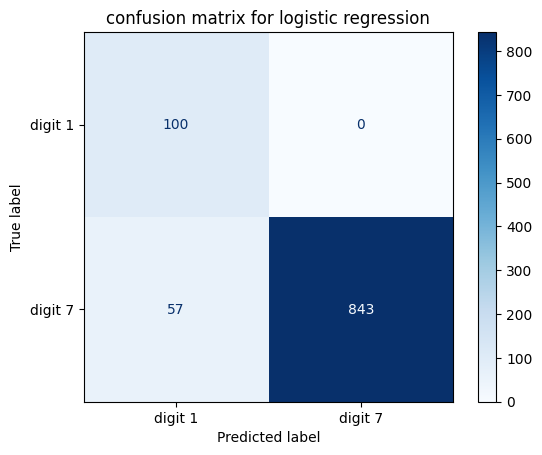

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# creating and displaying a confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm, display_labels=["digit 1", "digit 7"])
disp.plot(cmap = "Blues")
plt.title("confusion matrix for logistic regression")
plt.show()

for a more intuitive understanding of the classification report and it's outputs, we can use a confusion matrix and observe the predictions made by the model.

for example, the model made **57** incorrect predictions, thinking that the number under observation was 1, when it was actually 7.

--- 

if we were to consider **1 as the positive class** and **7 as the negative class** :

- **True Positive** (top left) = 100
- **False Negative** (top right) = 0
- **False Positive** (bottom left) = 57
- **True Negative** (bottom right) = 843

recall for digit 1 : $100 / (100 + 0) = 1$

precision for digit 1 : $100 / (100 + 57) = 0.64$

these metrics match what we saw in the classification report.

## Comparison of Two Classifiers and Hyperparameter Tuning

### Hyperparameter Variation

we will vary hyperparameter values across a decent range and determine the appropriate choice using k-fold cross validation.

#### Logistic Regression

for logistic regression, we will vary `C`, the regularization parameter. it controls how strictly the model fits the training data : 

- small `C` (e.g. 0.001) -> strong regularisation. model is kept simple = might underfit
- large `C` (e.g. 100) -> weak regularisation. model fits training data closely = might overfit

the initial accuracy of our model was 1 (100%) with the default value of 1. let's see if we get something different

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# values of C to try
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

# store mean f1 scores for each C
mean_f1_scores = []

# run C values through for loop for cross validation
for C in C_values:
    lr = LogisticRegression(C = C, random_state = 42, max_iter = 1000)
    # running 5-fold cross validation
    scores = cross_val_score(lr, X_train_flat, y_train, 
                             cv = 5, scoring = "f1_macro")
    mean_f1_scores.append(scores.mean())
    print(f" C = {C : .3f} | mean f1 : {scores.mean() : .4f} | std : {scores.std() : .4f}")

 C =  0.001 | mean f1 :  0.9599 | std :  0.0374
 C =  0.010 | mean f1 :  0.9799 | std :  0.0246
 C =  0.100 | mean f1 :  0.9900 | std :  0.0201
 C =  1.000 | mean f1 :  0.9900 | std :  0.0201
 C =  10.000 | mean f1 :  0.9900 | std :  0.0201
 C =  100.000 | mean f1 :  0.9900 | std :  0.0201


after a 1000 iterations each loop for different C values, we get the following results : 

- $C = 0.001$
    - f1 of 0.9599, std of 0.0374 = lower performance and more unstable
- $C = 0.01$
    - f1 jumps to 0.9799, std drops to 0.0246 = big improvement
- $C = 0.1$ and above
    - f1 falls flat to 0.9900, std stabalizes at 0.0201

let's try to visualize f1 scores with scaling values of C.

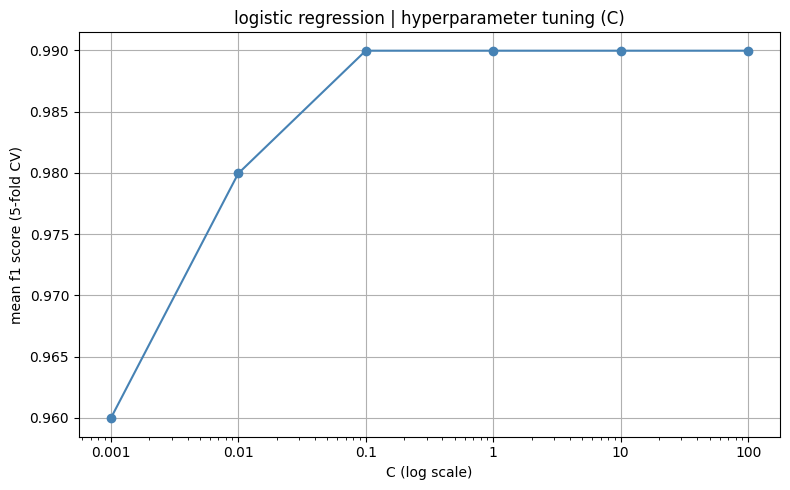

In [69]:
plt.figure(figsize = (8, 5))
plt.plot(C_values, mean_f1_scores, marker = "o", color = "steelblue")
# using log scale since C values are small and large
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("mean f1 score (5-fold CV)")
plt.title("logistic regression | hyperparameter tuning (C)")
plt.xticks(C_values, labels = [str(c) for c in C_values])
plt.grid(True)
plt.tight_layout()
plt.show()

we use the **xscale("log")** because the C parameters are very small and close to each other (0.001, 0.01, 0.1, 1) compare to the others (1, 10, 100). xscale scales / spaces things equally

we can clearly see the steep improvement and stabalization i mentioned earlier. there is no major improvement after C = 0.1. so we shall go ahead with that it.

In [70]:
best_lr = LogisticRegression(C = 0.1, random_state = 42, max_iter = 1000)
best_lr.fit(X_train_flat, y_train)

print("best logistic regression trained with C = 0.1")
print("training accuracy:", best_lr.score(X_train_flat, y_train))

best logistic regression trained with C = 0.1
training accuracy: 1.0


the accuracy doesn't change. this can be because : 

- the data is mostly linearly seperable
- we only have a 100 samples to train from 

when we tested this model with the untouched test data before, the results were pretty good. so our LR model most definitely isn't overfitting the training data. 

the true performance test will be measured when we test both models together.

#### Kernel SVM (RBF)

logistic regression can only draw a linear decision boundary between two classes. but if the data isn't linearly seperable, the performance may not be so good.

that is where kernel SVM comes in. 

we can use a wide variety of kernels to map our non-linear data in higher dimensions. for this assignment, i have chosen the RBF (radial basis function) kernel, which can map our original space into infinite dimensions.

a non-linear decision boundary may help us capture subtle differences.

In [14]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# defining the hyperparameter dictionary
param_grid = {
    "C" : [0.1, 1, 10, 100],
    "gamma" : [0.0001, 0.001, 0.01, 0.1]
}

# svm with the RBF kernel
svm = SVC(kernel = "rbf", random_state = 42)
# setting up grid search with 5-fold CV
grid_search = GridSearchCV(svm, param_grid, cv = 5, 
                           scoring = "f1_macro", verbose = 1)
# the verbose attribute will print our progress while grid search runs

grid_search.fit(X_train_flat, y_train)

print("\nbest parameters:", grid_search.best_params_)
print("best mean f1 score:", grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits

best parameters: {'C': 10, 'gamma': 0.001}
best mean f1 score: 1.0


we chose smaller values of gamma because we have a lot of featuers in each samples / image. 784 to be exact.

even if individual pixel differences are small for each term, summing them up across all 784 dimensions will create a large distance. 

$$||x - y||² = (x1 - y1)² + (x2 - y2)² + ... + (x784 - y784)²$$

let's say that each individual difference in the formula above averages to 0.01. summing 784 times makes the sum equal to 7.84.

plugging that value in with a default value of C as 1, we get

$$K(x, y) = exp(-γ × ||x - y||²)$$

$$K(x, y) = exp(-1 × 7.84) = exp(-7.84) ≈ 0.00039$$

that value is very close to zero. what that means is that the model may not detect a relationship between samples at all. and therefore, it can't learn any important patterns.

so it becomes really important to select a value of `gamma` that is very small.

---

we use grid search to try every possible combination of hyperparameters from the `param_grid` dictionary.

we have four `C` values and four `gamma` values, so we have **16 combinations**. and since we are running 5-fold CV, we will have $16 * 5 = 80$ runs.

since we use 5-fold CV, we only have 80 samples to train from and 20 samples to validate from. with such a small dataset, it's not too surprising that we get a perfect score. just like with logistic regression, we will have to see how the model performs with the test set.

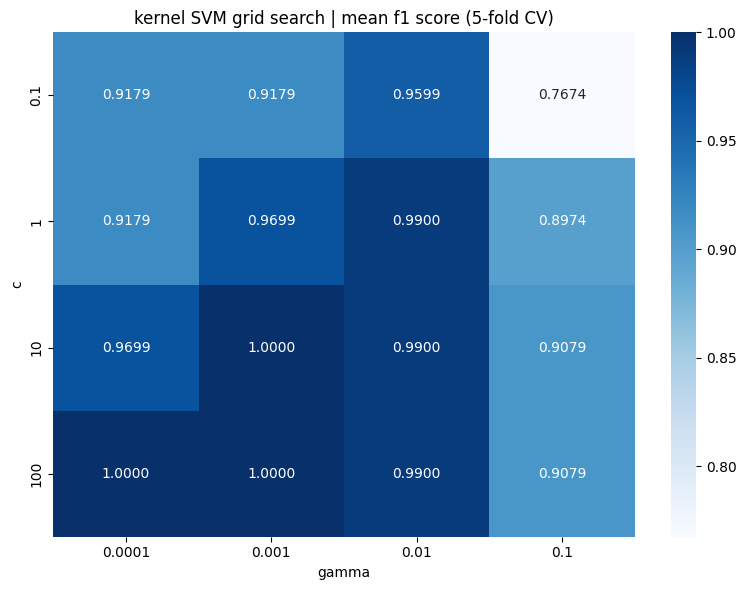

In [16]:
import seaborn as sns

# extract mean test scores and reshape into grid
results = grid_search.cv_results_
scores = results["mean_test_score"].reshape(4, 4)

# plot heatmap
plt.figure(figsize = (8, 6))
sns.heatmap(scores, 
            annot = True, 
            fmt = ".4f",
            xticklabels = [0.0001, 0.001, 0.01, 0.1],
            yticklabels = [0.1, 1, 10, 100],
            cmap = "Blues")

plt.xlabel("gamma")
plt.ylabel("c")
plt.title("kernel SVM grid search | mean f1 score (5-fold CV)")
plt.tight_layout()
plt.show()

we use a heatmap for visualizaiton because mapping 16 combinations with four parameters on just two axes is gonna get messy. a heat map creates a grid, which does a much better job at visualizing our results. color intensity makes things much easier to understand.

some interesting things to note about this heatmap : 

- as `gamma` increases, performance drops, as the model can't learn any meaningful observations.
- as a summary, hyperparameter `C` dictates how many misclassifications are allowed. a higher value of `C` creates a smaller margin, allowing less classifications. and since increasing `C` improves performance, this suggests that the data is fairly linearly seperable, which coincides with our assumption earlier.

---

$C = 10, gamma = 0.001$ is the correct choice. we get the same f1 score as with $C = 100$, but with a wider margin, which is simpler and generalises better.

In [71]:
# retraining a new SVM model with our best hyperparameters
best_svm = SVC(kernel = "rbf", C = 10, gamma = 0.001, random_state = 42)
best_svm.fit(X_train_flat, y_train)

print("best kernel SVM trained with C = 10, gamma = 0.001")
print("training accuracy:", best_svm.score(X_train_flat, y_train))

best kernel SVM trained with C = 10, gamma = 0.001
training accuracy: 1.0


the training accuracy for non-linear SVM is also 1, which is to be expected.

### Comparing model performance

we shall test the performance of the Logistic Regression and the Kernel SVM (RBF) on the test set. we will use the classification report from earlier to check performance with precision, recall and f1 score.

In [72]:
from sklearn.metrics import classification_report

# logistic regression predictions
y_pred_lr = best_lr.predict(X_test_flat)

# kernel SVM predictions
y_pred_svm = best_svm.predict(X_test_flat)

print("=" * 55)
print("logistic regression")
print("=" * 55)
print(classification_report(y_test, y_pred_lr, target_names = ["digit 1", "digit 7"]))

print("=" * 55)
print("kernel SVM (RBF)")
print("=" * 55)
print(classification_report(y_test, y_pred_svm, target_names = ["digit 1", "digit 7"]))

logistic regression
              precision    recall  f1-score   support

     digit 1       0.61      1.00      0.76       100
     digit 7       1.00      0.93      0.96       900

    accuracy                           0.94      1000
   macro avg       0.81      0.97      0.86      1000
weighted avg       0.96      0.94      0.94      1000

kernel SVM (RBF)
              precision    recall  f1-score   support

     digit 1       0.62      1.00      0.76       100
     digit 7       1.00      0.93      0.96       900

    accuracy                           0.94      1000
   macro avg       0.81      0.97      0.86      1000
weighted avg       0.96      0.94      0.94      1000



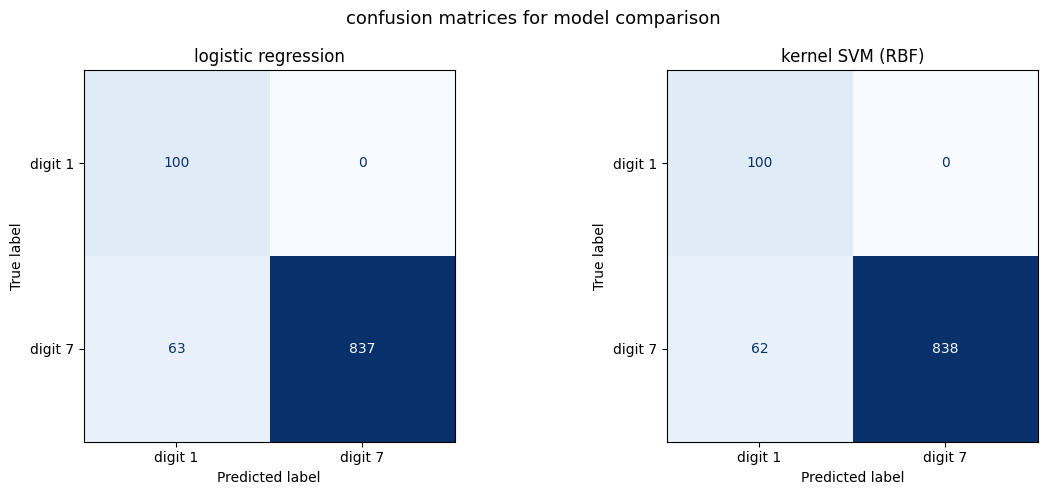

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize = (12, 5))
# creating confusion matrices for both the model for a side by side comparison
for ax, y_pred, title in zip(axes, 
                              [y_pred_lr, y_pred_svm], 
                              ["logistic regression", "kernel SVM (RBF)"]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels = ["digit 1", "digit 7"])
    disp.plot(ax = ax, colorbar = False, cmap = "Blues")
    ax.set_title(title)

plt.suptitle("confusion matrices for model comparison", fontsize = 13)
plt.tight_layout()
plt.show()

a small thing to note. the **performance of our logistic regression got slightly worse after the hyperparameter change**. this is because the hyperparameter tuning was done mainly on the training dataset, which created the performance gap. but thankfully, the performance gap is only minor.

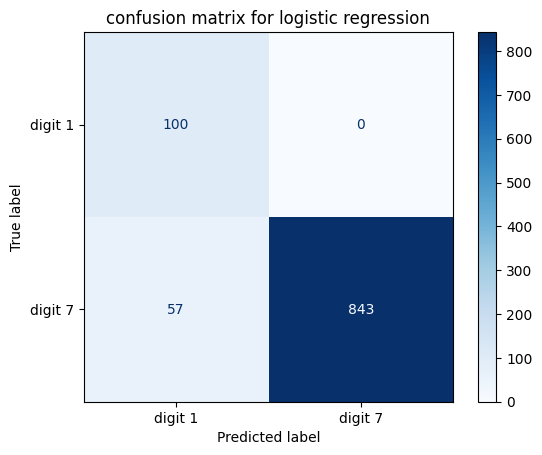

---

despite Kernel SVM (RBF) being more powerful and flexible, both classifiers have identical performance.

the way i interpret this, this test has proven that the **digits 1 and 7 are largely linearly seperable**. combined with the fact that we only have a 100 samples to train with, **we don't have enough complex data for our non-linear model to leverage it's potential**.

## Clustering Analysis of the Test Set

### Clustering the 7s from the test set

we utilize the information from the `y_test` to get all indices that correspond to the digit 7 from `X_test_flat`.

In [27]:
# create mask for digit 7 from test set
mask_7 = (y_test == 7)
# use mask to select features of digit 7 samples from test set
X_7 = X_test_flat[mask_7]

print("total test samples : ", len(X_test_flat))
print("digit 7 samples : ", len(X_7))
print("shape : ", X_7.shape)

total test samples :  1000
digit 7 samples :  900
shape :  (900, 784)


we get a total of 900 samples, which matches from earlier demonstrations, like the classification report.

In [33]:
from sklearn.cluster import KMeans

# fitting k-means with a hundred clusters
km100 = KMeans(n_clusters = 100, random_state = 42, n_init = 10)
km100.fit(X_7)

print("k-means with k = 100 fitted successfully !")
print("inertia:", km100.inertia_)

k-means with k = 100 fitted successfully !
inertia: 12519.339847503561


`n_init` runs k-means 10 different times with different random starting points, as k-means is infamous for getting stuck at a local minima. this gives us some options.

`inertia` measures the total distance of all points form their assigned centroid. it usually decreases as `K` increases.

to find the ideal `K` value, we shall use the elbow method.

--- 

as we increase `K`, `inertia` drops steeply, as each cluster adds a lot of value. at one point the change becomes small and gradual. that point is called the **elbow point**, the value of K that we are looking for.

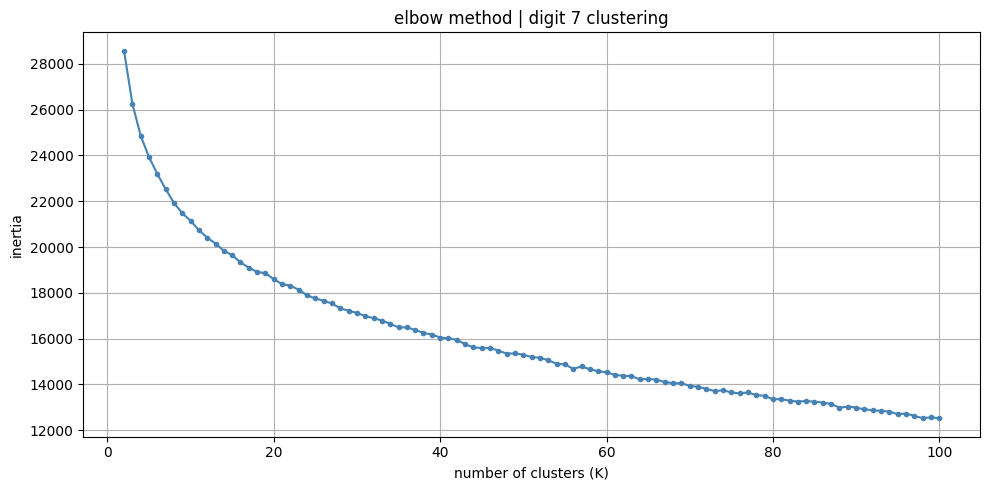

In [ ]:
# array to store inertia values for different k values
inertias = []
# k values will vary from 2 to 100
k_range = range(2, 101)

# looping through k_range and fitting k-means for each k value
for k in k_range:
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    km.fit(X_7)
    # append inertia value to list
    inertias.append(km.inertia_)

plt.figure(figsize = (10, 5))
plt.plot(list(k_range), inertias, marker = "o", markersize = 3, color = "steelblue")
plt.xlabel("number of clusters (K)")
plt.ylabel("inertia")
plt.title("elbow method | digit 7 clustering")
plt.grid(True)
plt.tight_layout()
plt.show()

the graph seems to steadily decrease after $k = 10$.

but still, this plot demonstrates a well known weakness of the elbow method. it can sometimes be ambiguous. therefore, we shall use a second method known as the **silhouette score**.

the score is calculate as follows : 

$$s = (b - a) / max(a, b)$$

where,

- a = average distance to other points within the same cluster
- b = average distace to other points in the nearest neighbouring cluster

K = 2 | silhouette score: 0.1217
K = 3 | silhouette score: 0.1087
K = 4 | silhouette score: 0.1009
K = 5 | silhouette score: 0.0814
K = 6 | silhouette score: 0.0797
K = 7 | silhouette score: 0.0811
K = 8 | silhouette score: 0.0725
K = 9 | silhouette score: 0.0727
K = 10 | silhouette score: 0.0700
K = 11 | silhouette score: 0.0636
K = 12 | silhouette score: 0.0710
K = 13 | silhouette score: 0.0683
K = 14 | silhouette score: 0.0703
K = 15 | silhouette score: 0.0655
K = 16 | silhouette score: 0.0632
K = 17 | silhouette score: 0.0687
K = 18 | silhouette score: 0.0690
K = 19 | silhouette score: 0.0526
K = 20 | silhouette score: 0.0670
K = 21 | silhouette score: 0.0670
K = 22 | silhouette score: 0.0626
K = 23 | silhouette score: 0.0615
K = 24 | silhouette score: 0.0608
K = 25 | silhouette score: 0.0658
K = 26 | silhouette score: 0.0616
K = 27 | silhouette score: 0.0640
K = 28 | silhouette score: 0.0637
K = 29 | silhouette score: 0.0627
K = 30 | silhouette score: 0.0584
K = 31 | silhouette sc

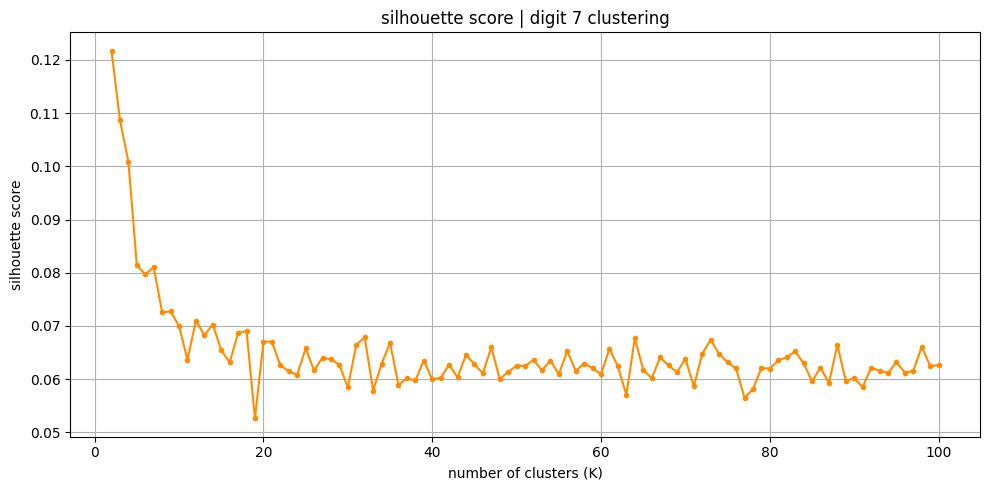

In [ ]:
from sklearn.metrics import silhouette_score

# same range of values used as in for the inertia 
sil_scores = []
k_range = range(2, 101)

for k in k_range:
    # fitting k-means for each k value and calculating silhouette score
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = km.fit_predict(X_7)
    sil_scores.append(silhouette_score(X_7, labels))
    # values will be printed as we go
    print(f"K = {k} | silhouette score: {sil_scores[-1]:.4f}")

plt.figure(figsize = (10, 5))
plt.plot(list(k_range), sil_scores, marker = "o", markersize = 3, color = "darkorange")
plt.xlabel("number of clusters (K)")
plt.ylabel("silhouette score")
plt.title("silhouette score | digit 7 clustering")
plt.grid(True)
plt.tight_layout()
plt.show()

the silhoutte score drops sharply after $k = 2$ and more or less stabalizes after $k = 10$.

$k = 10$ seems to be the correct choice.

### Cluster Analysis

In [41]:
# new k-means with the appropriated k value
km_final = KMeans(n_clusters = 10, random_state = 42, n_init = 10)
labels = km_final.fit_predict(X_7)
# store cluster centers for future use
centers = km_final.cluster_centers_

print("final k-Means fitted with K = 10")
# show the shape of a cluster center
print("cluster centres shape:", centers.shape)

# display how many samples are in each cluster
for i in range(10):
    print(f"cluster {i} : {np.sum(labels == i)} samples")

final k-Means fitted with K = 10
cluster centres shape: (10, 784)
cluster 0 : 107 samples
cluster 1 : 79 samples
cluster 2 : 67 samples
cluster 3 : 121 samples
cluster 4 : 81 samples
cluster 5 : 100 samples
cluster 6 : 69 samples
cluster 7 : 128 samples
cluster 8 : 79 samples
cluster 9 : 69 samples


a few observations to note here : 

- the shape of the cluster center is (10, 784). one 784 dimension centroid per cluster
- cluster sizes range from 67 to 128 samples. this is a reasonable average. no cluster dominates and no cluster is mostly empty

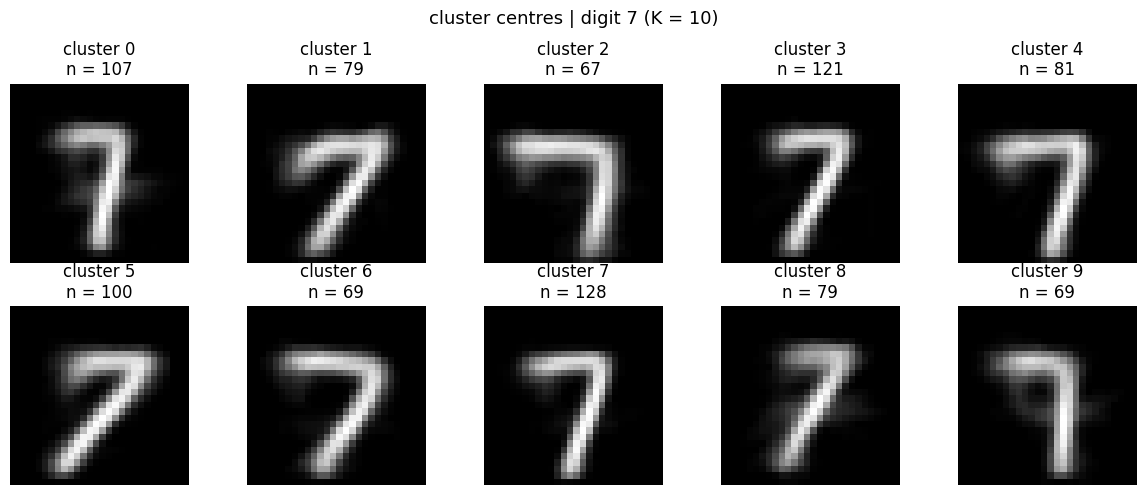

In [ ]:
fig, axes = plt.subplots(2, 5, figsize = (12, 5))
axes = axes.flatten()

for i in range(10):
    # mapping the cluster center back to 28x28 to create an image
    # center array stores cluster centers from previous cell
    axes[i].imshow(centers[i].reshape(28, 28), cmap = "gray")
    axes[i].set_title(f"cluster {i}\nn = {np.sum(labels == i)}")
    axes[i].axis("off")

plt.suptitle("cluster centres | digit 7 (K = 10)", fontsize = 13)
plt.tight_layout()
plt.show()

mathematically, the centroid of each cluster is just the average of each image (with 784 features each) within that cluster.

in other words, a centroid is the average feature collection from each cluster and represents what each image in that cluster looks like, more or less. we can map the centroid back to (28, 28) from (784, ) and make an image out of it.

the visualization clearly shows us what the centroids mean from a non-technical standpoint. **each centroid represents the difference in writing style for each 7 in our dataset, purely based on pixel similarities**.

some style differences that i can make out : 

- 7s from `clusters 0 and 9` stand upright
- 7s from `cluster 1` slouch
- 7s from `cluster 5 and 8` slanted
- 7s from `cluster 2` have longer "heads" than the others

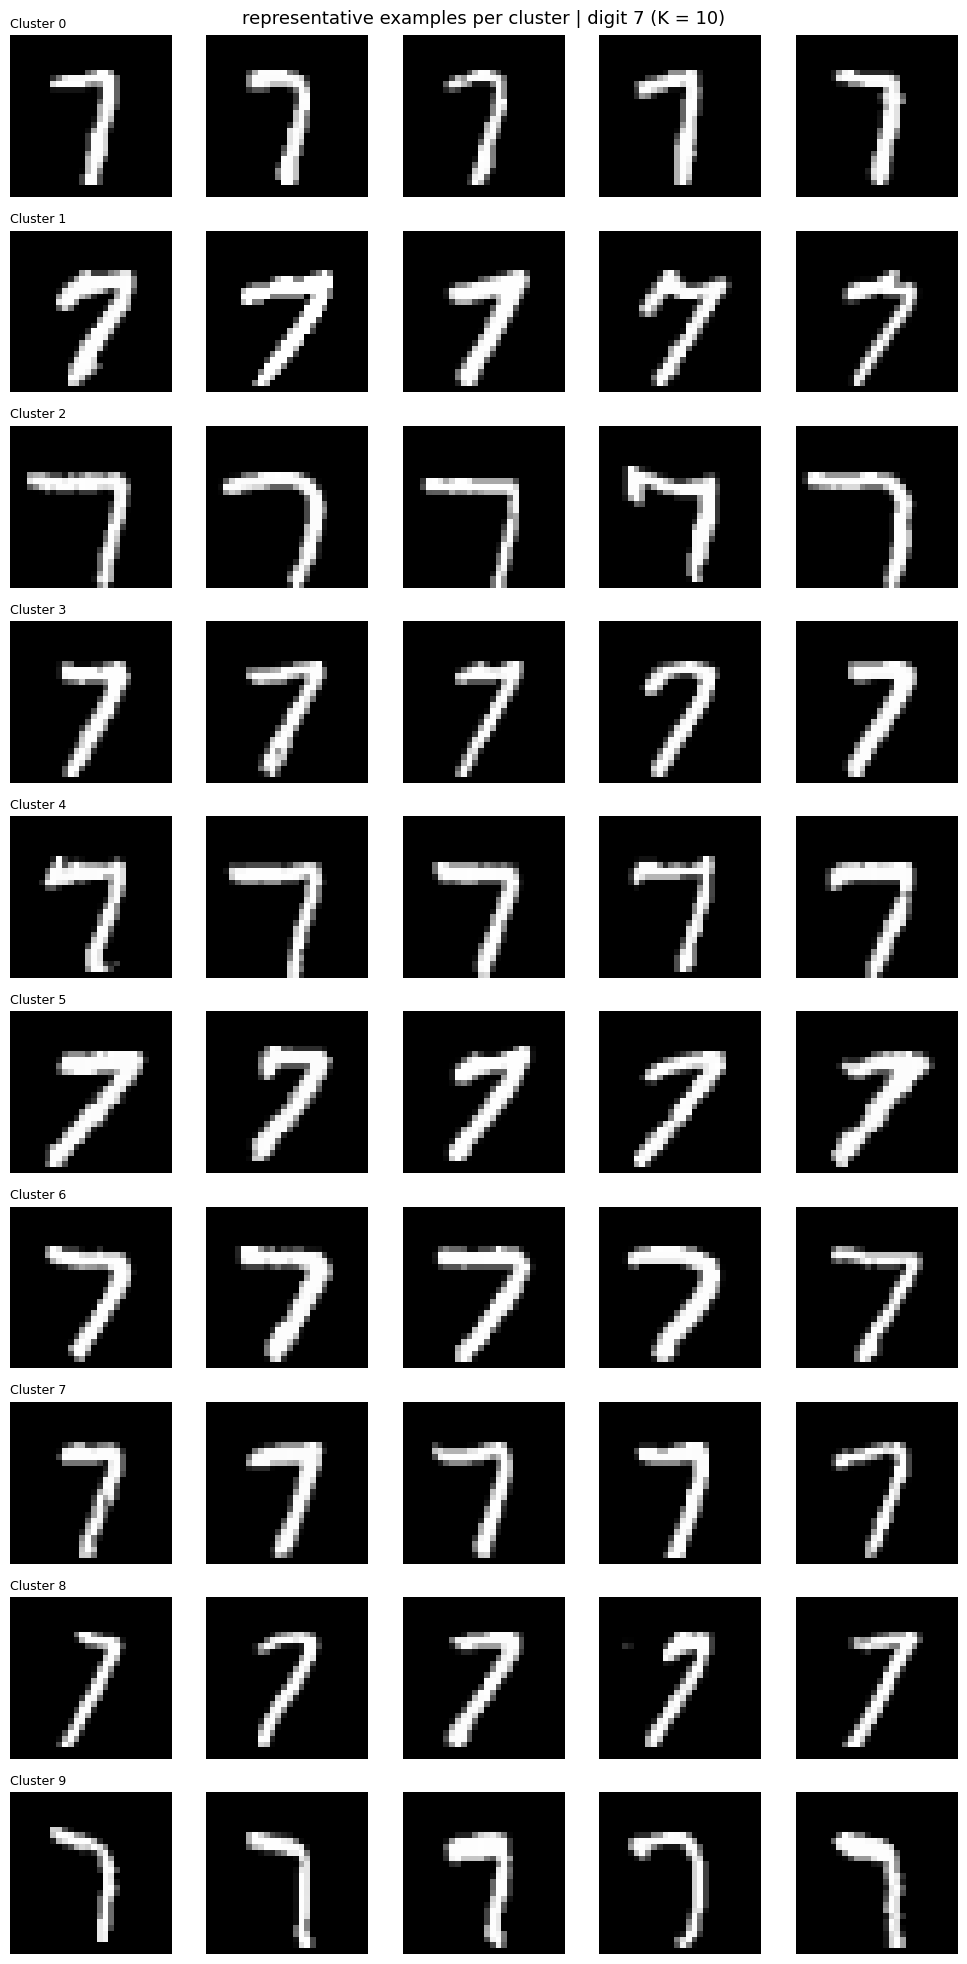

In [60]:
fig, axes = plt.subplots(10, 5, figsize = (10, 20))

# range 1 to 10 represents the cluster numbers (0 to 9)
for i in range(10):
    # get indices of samples in this cluster
    cluster_idxs = np.where(labels == i)[0]

    # calculate distance of each sample to its centroid
    dists = np.linalg.norm(X_7[cluster_idxs] - centers[i], axis = 1)

    # get 5 closest samples to that centroid
    closest_idxs = cluster_idxs[np.argsort(dists)[:5]]
    
    for j, idx in enumerate(closest_idxs):
        axes[i, j].imshow(X_7[idx].reshape(28, 28), cmap = "gray")
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(f"Cluster {i}", fontsize = 9, loc = "left")

plt.suptitle("representative examples per cluster | digit 7 (K = 10)", 
             fontsize = 13)
plt.tight_layout()
plt.show()

the differences in the writing styles observed from the centroids plot are clearly reflected in the images belonging to those clusters.